In [90]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [91]:
ssplist = ["126","245","370","585"]

ssplistplot = ["hist","126","245","370","585"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1950,2100]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1980,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 10
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
# modelfilefront = "MPI_histrecord_"
modelfilefront = "MPI_recordtemp_"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

device = 'mps'


data/MPI_annualmean_126_tos_1900-2100.pkl
data/MPI_annualmean_245_tos_1900-2100.pkl
data/MPI_annualmean_370_tos_1900-2100.pkl
data/MPI_annualmean_585_tos_1900-2100.pkl


In [92]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [93]:
landmask = np.isnan(np.nanmean(AllObs.alloutput,axis=0))

In [94]:
obsnull = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
obsaccuracy = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obs_bs = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
lr_bs = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

lr_acc = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

obsfirstpositive = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

allbaselines = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan
baseline_percentile = np.empty((len(AllObs.output_lat),len(AllObs.output_lon)))+np.nan

allobspredictions = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),lenobs))+np.nan
allrecordmags = np.empty((len(AllObs.output_lat),len(AllObs.output_lon),lenobs))+np.nan

for ilat,lat in enumerate(AllObs.output_lat):

    for ilon,lon in enumerate(AllObs.output_lon):

        metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed*.json"
        filelist = glob.glob(metricsout)

        if len(filelist)!=0:
            # print('models exist, proceeding')

            bestseeds = helpers.get_best_files(filelist,n_best)
            obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_histrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)
            # obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,lat,lon)

            obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
            obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
            obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)
            obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

            # print(bestseeds)
            obsnull[ilat,ilon] = np.max([np.mean(obsoutput),1-np.mean(obsoutput)])

            obspredall = np.empty((3,len(obsinputgmt)))

            for iseed,seed in enumerate(bestseeds):
                # load the model

                loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
                cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
                cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
                cnn.to(device)

                with torch.no_grad():
                    cnn.eval()
                    obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

                obspredall[iseed] = obspred[:,1]

            obspredavg = np.mean(obspredall,axis=0)
            obspredclass = np.round(obspredavg)

            obsaccuracy[ilat,ilon] = np.mean(obsoutput==obspredclass)
            obsfirstpositive[ilat,ilon] = helpers.firstpositive(obspredavg,obsinputgmt)

            obs_bs[ilat,ilon] = helpers.brierscore(obspredavg.squeeze(),obsoutput.squeeze())

            lrmodelload = "lr_models/"+modelfilefront + "LogisticRegression_avgtime_"+str(outputavgtime)+"_lat_"+str(lat)+"_lon_"+str(lon)+".joblib"
            lrmodel = joblib.load(lrmodelload)

            lrpred = lrmodel.predict_proba(obsinputvectors_t[:,[0]].numpy())[:,1]
            lr_bs[ilat,ilon] = helpers.brierscore(lrpred,obsoutput.squeeze())
            lr_acc[ilat,ilon] = np.mean(np.round(lrpred)==obsoutput.squeeze())

            # allbaselines[ilat,ilon] = AllObs.baseline
            # baseline_percentile[ilat,ilon] = AllObs.baselinepercentile

            if lat<0:
                allobspredictions[ilat,ilon] = obspredavg
                # allrecordmags[ilat,ilon] = AllObs.recordmags[inputlength:-1*(outputavgtime)]
            else:
                allobspredictions[ilat,ilon] = obspredavg[1:]
                # allrecordmags[ilat,ilon] = AllObs.recordmags[inputlength:-1*(outputavgtime)]
        # else:
            # print('no model for '+ str(lat) + ' ' + str(lon))



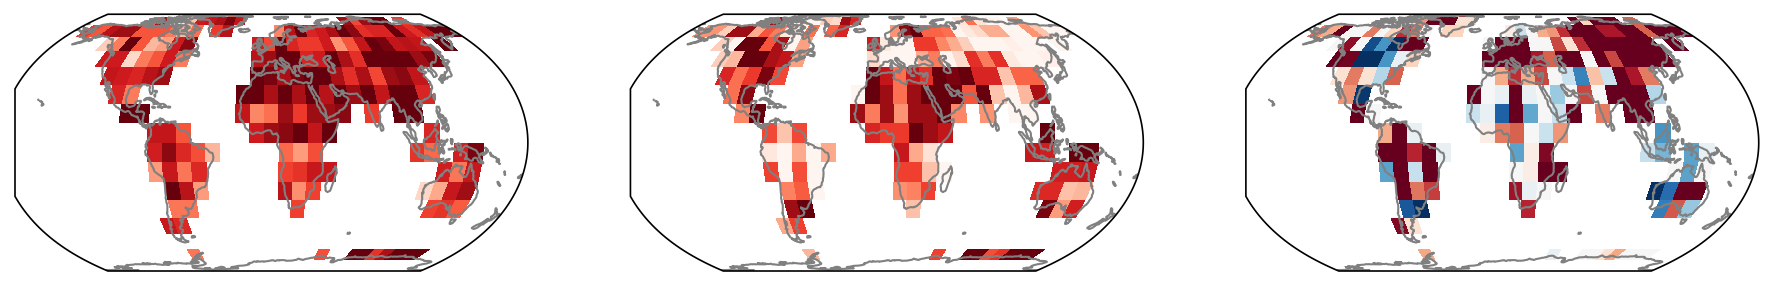

In [101]:
plt.figure(figsize=(15,5))

obsaccuracy[landmask] = np.nan
lr_acc[landmask] = np.nan


ax=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,lr_acc,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsaccuracy-(lr_acc),vmin=-0.5,vmax=0.5,cmap="RdBu_r",transform=ccrs.PlateCarree())

ax.coastlines(color='gray')

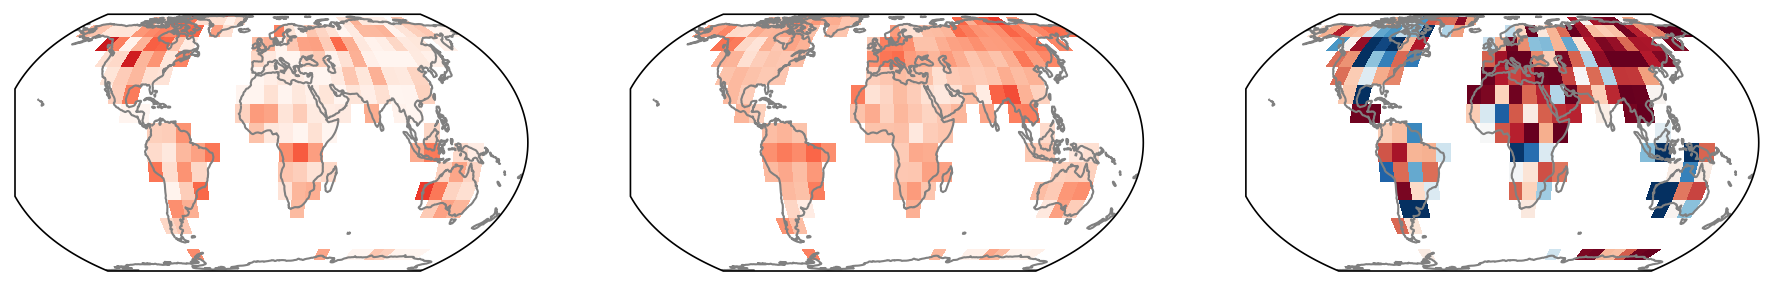

In [102]:
obs_bs[landmask] = np.nan
lr_bs[landmask] = np.nan

plt.figure(figsize=(15,5))

ax=plt.subplot(1,3,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obs_bs,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,2,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,lr_bs,vmin=0,vmax=1,cmap='Reds',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

ax=plt.subplot(1,3,3,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,1-(obs_bs/lr_bs),vmin=-1,vmax=1,cmap="RdBu_r",transform=ccrs.PlateCarree())

ax.coastlines(color='gray')

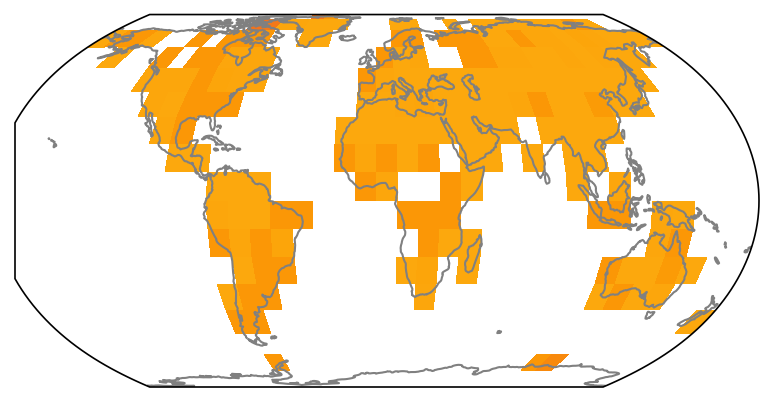

In [97]:
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,obsfirstpositive,vmin=-0.5,vmax=3,cmap='inferno_r',transform=ccrs.PlateCarree())
ax.coastlines(color='gray')

In [98]:
obsinputgmt.shape

(27, 1)

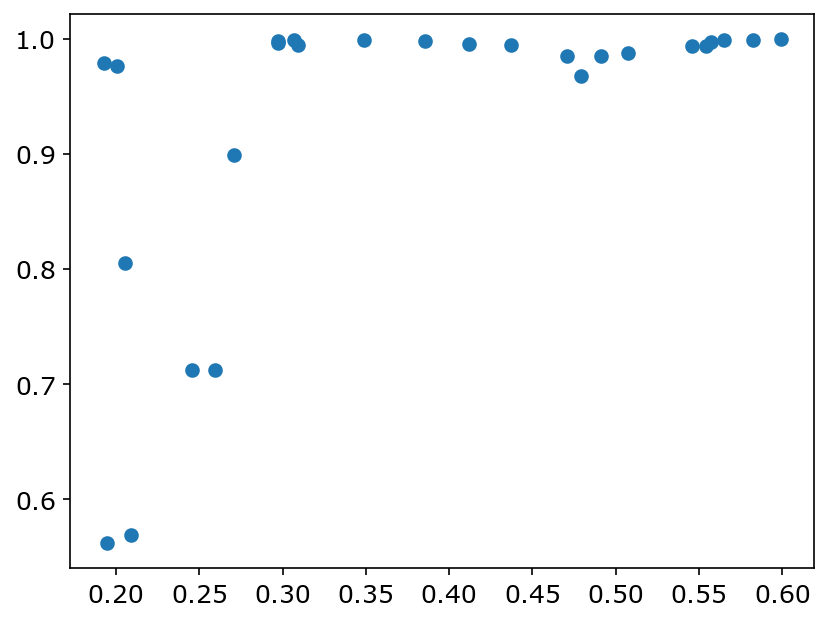

In [99]:
plt.scatter(obsinputgmt.squeeze()[1:],allobspredictions[12,6])


ValueError: x and y must have same first dimension, but have shapes (51,) and (26,)

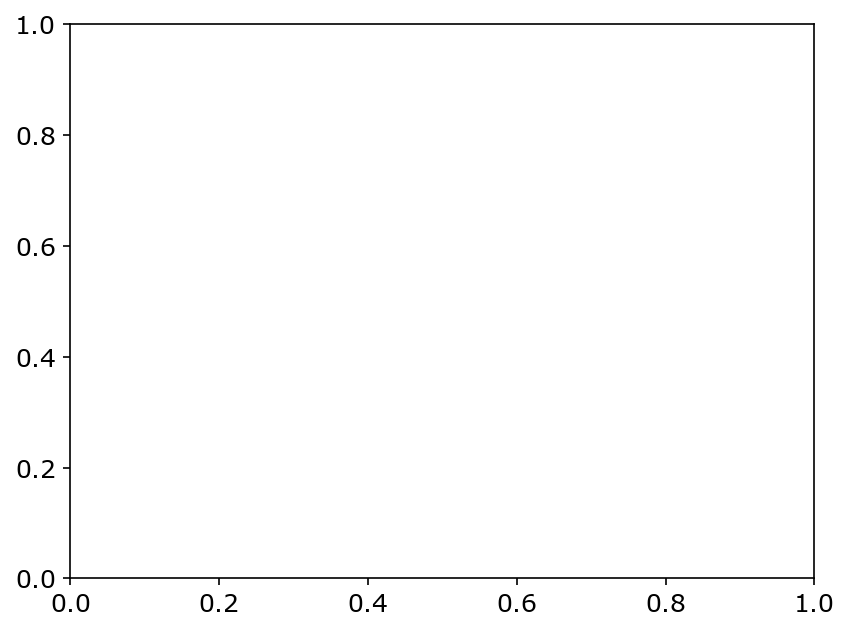

In [100]:
plt.plot(np.arange(1970,2021),allobspredictions[12,6])

In [ ]:
# select a gridpoint

latsel = -50
lonsel = 170

metricsout = "metrics/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed*.json"
filelist = glob.glob(metricsout)

if len(filelist)!=0:
    print('models exist, proceeding')

    bestseeds = helpers.get_best_files(filelist,n_best)
    obsinput,obsinputgmt,obsinputpriorrecord,obsoutput = AllObs.obs_recordmax_withrecordmax(experiment_era_obs,baselineera_obs,inputlength,outputavgtime,latsel,lonsel)

    obsinput_t = torch.tensor(obsinput,dtype=torch.float32)
    obsinputgmt_t = torch.tensor(obsinputgmt,dtype=torch.float32)
    obsinputpriorrecord_t = torch.tensor(obsinputpriorrecord,dtype=torch.float32)

    obsinputvectors_t = torch.cat((obsinputgmt_t,obsinputpriorrecord_t),axis=-1)

    print(bestseeds)
    obsnull[ilat,ilon] = np.mean(obsoutput)

    obspredall = np.empty((3,len(obsinputgmt)))

    for iseed,seed in enumerate(bestseeds):
        # load the model

        loadfile = "models/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(latsel)+"_lon_"+str(lonsel)+"_seed_"+str(seed)+".pt"
        cnn = buildmodel.CNNclassifier(obsinput_t, obsinputvectors_t, 2).to('cpu')
        cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
        cnn.to(device)

        with torch.no_grad():
            cnn.eval()
            obspred = cnn(obsinput_t.to(device), obsinputvectors_t.to(device)).cpu().numpy()

        obspredall[iseed] = obspred[:,1]
else:
    print('no model')

models exist, proceeding
[18469465 47621498 92895735]


In [ ]:
AllObs.outputsummer

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan])

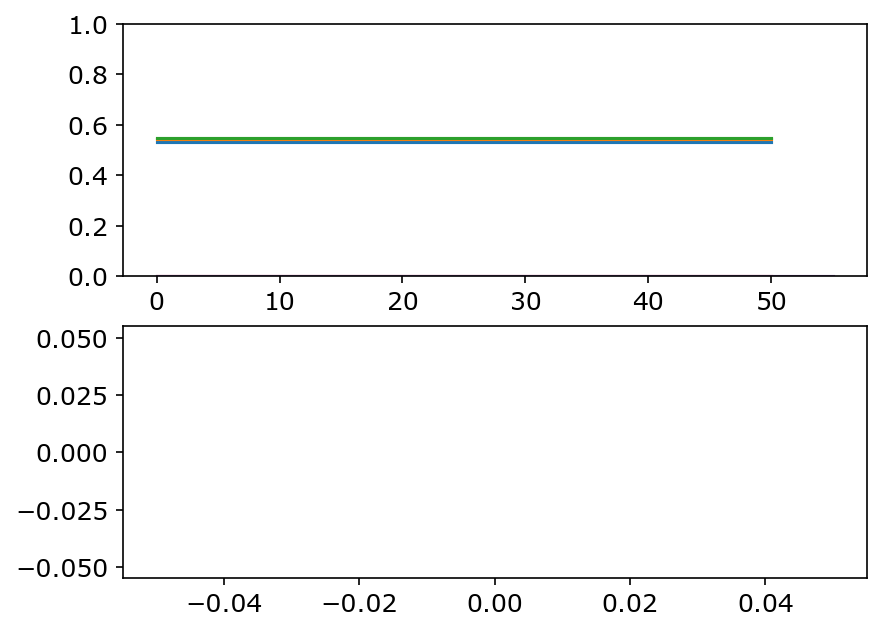

In [ ]:
yearvec = np.arange(experiment_era_obs[0]+inputlength,experiment_era_obs[1]-outputavgtime+1)

plt.subplot(2,1,1)
plt.plot(np.transpose(obspredall))
plt.plot(obsoutput)
plt.plot(AllObs.recordtemps[10:])

plt.ylim(0,1)

plt.subplot(2,1,2)
plt.plot(AllObs.outputsummer[10:]-273)